# 解答例（教員用）　第8回
***
> このノートブックは **模範解答の一例**です．コードの空欄（`TODO()`）を埋め，実験の組合せを広げて実行し，解答欄には実際に得られた出力の数値を根拠に書いています．
> 乱数を使う箇所は固定していますが，ライブラリのバージョンや実行環境によって数値が **小数第2〜3位ほどずれる**ことがあります．設計判断の問題は「正解は1つ」ではないので，**別の選択でも，根拠が筋の通っていれば正解**です．

# 第8回　前処理と Pipeline
***
> **前提**: 第5回（タイタニック）で学んだ前処理を発展させます。第5回は `dropna` で欠損を除去しましたが、本回は**補完**と **Pipeline** で自動化します。

> ⚠️ **この課題で身につけること：コーディングではなく「AI（機械学習）の中身の理解」です。**
>
> コードは AI に書かせても構いません。重要なのは「**なぜその処理を選ぶのか**」「**パラメータや特徴量を変えると結果がどう変わるのか**」を理解し、提出物で示すことです。各問には学習目標を示すタグが付いています。
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（数値・選択肢・特徴量）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータ等を変えて結果を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります（空欄は `TODO()` と書いてあり、そのまま実行すると「空欄が残っています」というエラーで止まります。`TODO()` を自分のコードに書き換えてください）。AI に頼り切らず、要となる処理は自分で書けることも確認します（ボイラープレートは提供済み）。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

## 目次
1. データの読み込み
2. 欠損値の確認と補完
3. ColumnTransformer と Pipeline
4. モデル評価

---

## この回で学ぶこと

### なぜ前処理が重要なのか

現実のデータは必ず「汚れている」。欠損値・外れ値・スケールの違いを放置したままモデルを学習させると，精度が著しく落ちたり，最悪の場合モデルが全く機能しない。前処理はデータサイエンスの作業時間の **60〜80%** を占めると言われており，卒業研究でも避けられないスキルだ。

### 欠損値補完（Imputation）

欠損値の扱いには大きく3つの方針がある：

| 方針 | 方法 | いつ使うか |
|---|---|---|
| 削除 | `dropna()` | 欠損が全体の5%未満，かつランダムに欠損している場合 |
| 統計値で補完 | `SimpleImputer` | 欠損が多く削除できない場合（本回） |
| モデルで予測補完 | `IterativeImputer` など | 欠損パターンに意味がある場合（発展） |

`SimpleImputer` の `strategy` の違い：
- `"mean"` : 外れ値の影響を受けやすい。正規分布に近いデータに向く
- `"median"` : 外れ値に強い。**右に歪んだデータに推奨**
- `"most_frequent"` : カテゴリ変数や欠損率が低い数値列に向く

### スケーリング（正規化・標準化）— 列ごとに「数字の大きさ」が違う問題

第5回と同じタイタニックデータでは，数値列の**桁**がバラバラです（問題1でも同じ7列を使います）。

| 列 | だいたいの範囲 | 意味のイメージ |
|---|---|---|
| `Pclass` | 1〜3 | 客室クラス（数字が小さいほど上等） |
| `Age` | 0〜80 歳前後 | 年齢 |
| `Fare` | 0〜500 前後 | 運賃（最大値が `Pclass` よりずっと大きい） |

**なぜ気にするか**：一部のモデルは「数値の大小そのもの」で比較します。`Fare` が 200・`Pclass` が 2 のとき，モデルが「200 と 2 の差の大きさ」をそのまま見ると，**運賃の方が圧倒的に重要そうに見える**ことがあります。スケーリングは，各列のスケールを揃えて，**列同士を公平に比較しやすくする**前処理です。

| 手法 | ざっくりした変換 | 特徴 |
|---|---|---|
| `StandardScaler` | 平均0・ばらつき1くらいにそろえる | 最もよく使われる。外れ値があると平均と標準偏差が引っ張られる |
| `MinMaxScaler` | 最小0・最大1に押し込む | 0〜1 に揃う。最大・最小だけで決まるので外れ値に特に弱い（外れ値が多いときは `RobustScaler`） |

**スケーリングが効くモデル・効かないモデル**：スケーリングが効くかどうかは**モデルによって違います**。問題2では次の2つを比べます。

| モデル | 判断のしかた | スケーリングの影響 |
|---|---|---|
| 決定木（`"tree"`） | 「`Age` は 25 より大きいか？」のように**1列ずつしきい値で分岐** | ほぼ受けない（どう確かめられるかは問題2で） |
| k 近傍法 KNN（`"knn"`） | 「**距離**が近い k 人の多数決」。距離は全列の差をまとめて計算する | 受ける（どう受けるかは問題2で） |

### Pipeline の本当の価値：データリーク防止

Pipeline を使わずに手動で `fit_transform` すると，テストデータの情報が訓練データの統計量に混入する「**データリーク（Data Leakage）**」が起きる危険がある。

```
【NG例：データリーク】
scaler.fit_transform(X_all)  # テストデータの情報も含めて統計量を計算 → NG
X_train, X_test = split(X_all_scaled)

【OK例：Pipeline】
pipeline.fit(X_train, y_train)   # 訓練データだけで統計量を計算
pipeline.predict(X_test)          # 訓練データの統計量でテストデータを変換 → OK
```

卒業研究では「テストデータの情報が前処理やパラメータ選びに混入して，論文の精度が実際より高く出ていた」という失敗がよく起こる。Pipeline は前処理の統計量を**訓練データだけ**から学習させることで，この種のリークを防ぐ設計思想だ（なお時系列データの「未来の情報の混入」は分割方法の問題で，Pipeline だけでは防げない。下の研究メモ参照）。

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 医学・公衆衛生 | 患者データの欠損補完，検査値の標準化，予後予測の前処理パイプライン |
| 社会学・経済学 | アンケート・行政データ（欠損・カテゴリ混在）の再現可能な前処理 |
| 心理学・教育学 | 縦断調査データで，訓練/検証分割後にのみ統計量を計算する設計 |
| 情報科学 | 表形式データの機械学習実験全般（Kaggle でも Pipeline は標準） |

### 応用できる場面

- **表形式データ**（CSV，データベース）で，数値列とカテゴリ列が混在している
- 欠損値があり，「削除するとサンプルが足りなくなる」場合
- **再現性**が求められる（論文・卒論で「同じ手順を他者が再実行できる」必要がある）
- `train_test_split` の**後**に前処理を行い，**データリークを防ぎたい**とき（本回の Pipeline の本質）

### 応用しにくい・向かない場面

- **生画像・生テキスト**：`ColumnTransformer` ではなく，畳み込みやトークナイズなど別の前処理が必要（第14回以降）
- **時系列データ**：単純なランダム分割は未来情報のリークになりうる。時系列用の分割（`TimeSeriesSplit` など）が別途必要
- **因果推論**：「どの変数が原因か」を Pipeline だけでは答えられない（相関と因果は別問題）
- **データがきれいで少ない**：前処理の選択肢を比較する余地が小さく，本格的な実験設計の練習にはなりにくい

### 研究で報告するときのポイント

1. **前処理の手順を論文に書く**（補完方法，スケーラ，カテゴリの符号化）— 再現性のため
2. **どのデータで統計量を計算したか**を明記（訓練のみ vs 全体）— リーク防止の証明
3. 前処理の違いが結果に与える影響を示すと，査読で信頼されやすい

### 関連する発展トピック（調べてみると良い）

- `IterativeImputer`（多変量による欠損補完）
- `Feature-engine` や `sklearn-pandas`（複雑な前処理の自動化）
- MLOps における「学習パイプラインと推論パイプラインの一致」（第17回の Distribution Shift とつながる）


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

import pandas as pd

TITANIC_URL = "https://raw.githubusercontent.com/ShotaYmzk/AI-kadai/main/data/titanic/titanic.csv"

def load_titanic() -> pd.DataFrame:
    return pd.read_csv(TITANIC_URL)


def TODO():
    """「★あなたが書く★」の空欄。自分のコードに置き換えるまで、実行するとここで止まる。"""
    raise NotImplementedError("★あなたが書く★ の空欄（TODO()）がまだ残っています。自分のコードに書き換えてから再実行してください。")


## 問題1　データの読み込みと欠損確認　【骨格+選択】
***

### 背景

分析を始める前に必ず「データの全体像を把握する」ことが重要。列の型・サンプル数・欠損数を確認しないまま進めると，後で予期しないエラーや誤った分析に繋がる。これは研究でも実務でも最初に必ずやるべきステップです。

各列の意味：
- `Survived` : 生存フラグ（0=死亡, 1=生存）→ **予測したい目的変数**
- `Pclass` : 客室クラス（1=一等, 2=二等, 3=三等）→ 社会的地位の代理変数
- `Sex` : 性別（male/female）→ カテゴリ変数なので後でエンコードが必要
- `Age` : 年齢 → **欠損が多い列（約20%）**
- `SibSp` / `Parch` : 同乗する兄弟姉妹数 / 親子数
- `Fare` : 運賃 → 右に裾が長い分布（外れ値あり）

### 課題

読み込みとヒストグラム描画は用意してあります。**核心の1行（各列の欠損数を求める処理）だけ自分で書いて**（`# ★あなたが書く★`）からセルを実行し、出力を観察してください。

観察したうえで、次の **設計判断** に答え、**解答用コードセル**に記入してください。

> **設計判断1**: `Age` 列は約20%が欠損しています。この欠損をどう扱うべきか、次の選択肢から**1つ選び、理由**を解答用コードセルに書いてください。ここでの選択は問題2の補完方法にそのまま使います。
>
> - **(A) 行ごと削除（`dropna`）** … 欠損行を捨てる
> - **(B) 平均値で補完（`mean`）**
> - **(C) 中央値で補完（`median`）**
> - **(D) 最頻値で補完（`most_frequent`）**
> - **(E) 定数（例: 0）で補完** … 欠損であること自体を一つの値とみなす
> - **(F) 他の特徴量から予測して補完（`IterativeImputer` など）** … Pclass や Fare から Age を推定
>
> ヒント：**欠損率% の Age 行**を (1-a) に書く。(1-b) の「歪み」は下の**参考図**と，実データのヒストグラム・歪度で判断する。「正解は1つ」ではなく，**根拠が筋の通った選択**が重要。(E)(F) のデメリットも考えると説得力が増す。

### 参考：分布の「歪み」の見え方（下のセルを実行）

「**山（峰）がどちらにあるか**」ではなく，「**どちら側に長い裾（少数の極端な値）があるか**」で左右を決める。

| 呼び方 | 裾の向き | 歪度の目安 | イメージ |
|---|---|---|---|
| 左右対称 | 左右とも短い | 0 に近い | 正規分布のような形 |
| **右に歪む** | **右側**に裾 | **正（>0）** | 若年に山があり，高齢側に少数がのびる |
| 左に歪む | 左側に裾 | 負（<0） | 高齢に山があり，若年側に少数がのびる |

よくある誤解：「グラフの左に山がある＝左に歪む」ではない。


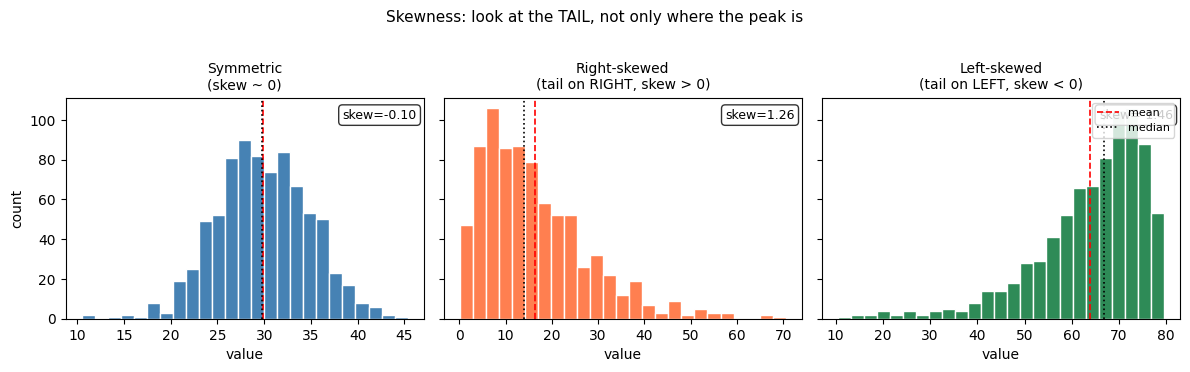

Age (Titanic) はこの中のどれかに似ているはずです。


In [2]:
# === 参考図：分布の歪み（実行するだけ。記入不要）===
rng = np.random.default_rng(0)

symmetric = rng.normal(30, 5, 800)
right_skew = rng.gamma(shape=2.0, scale=8.0, size=800)   # 左に山・右に裾（Age に近いイメージ）
left_skew = 80 - rng.gamma(shape=2.0, scale=8.0, size=800)  # 右に山・左に裾

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
examples = [
    (symmetric, "Symmetric\n(skew ~ 0)", "steelblue"),
    (right_skew, "Right-skewed\n(tail on RIGHT, skew > 0)", "coral"),
    (left_skew, "Left-skewed\n(tail on LEFT, skew < 0)", "seagreen"),
]

for ax, (data, title, color) in zip(axes, examples):
    ax.hist(data, bins=25, color=color, edgecolor="white")
    ax.axvline(data.mean(), color="red", linestyle="--", linewidth=1.2, label="mean")
    ax.axvline(np.median(data), color="black", linestyle=":", linewidth=1.2, label="median")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("value")
    skew_val = pd.Series(data).skew()
    ax.text(0.98, 0.95, f"skew={skew_val:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

axes[0].set_ylabel("count")
axes[2].legend(loc="upper right", fontsize=8)
fig.suptitle("Skewness: look at the TAIL, not only where the peak is", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("Age (Titanic) はこの中のどれかに似ているはずです。")


形式 (行数, 列数): (891, 7)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 48.9 KB

各列の欠損数 / 欠損率(%):
          欠損数  欠損率%
Survived    0   0.0
Pclass      0   0.0
Sex         0   0.0
Age       177  19.9
SibSp       0   0.0
Parch       0   0.0
Fare        0   0.0


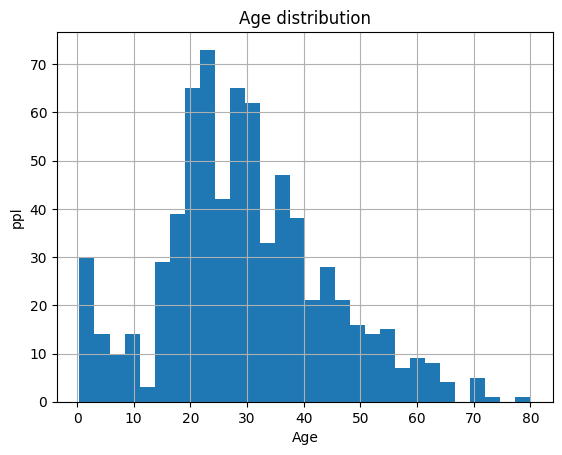

歪度（正なら右に歪む）: 0.389


In [3]:
# === 用意済み：データの読み込み ===
USE_COLS = ["Survived", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
df_titanic = load_titanic()[USE_COLS].copy()

print("形式 (行数, 列数):", df_titanic.shape)
df_titanic.info()

# ★あなたが書く★：各列の「欠損数」を求めて missing に代入する（1行）
#   ヒント: DataFrame には欠損を数えるメソッドがある（isnull / isna と sum の組み合わせ）
missing = df_titanic.isnull().sum()   # 各列の欠損数（True=欠損 を列ごとに合計）

# === 用意済み：欠損率の計算と表示 ===
missing_rate = (missing / len(df_titanic) * 100).round(1)
print("\n各列の欠損数 / 欠損率(%):")
print(pd.concat([missing.rename("欠損数"), missing_rate.rename("欠損率%")], axis=1))

# Age の分布（参考図の「右に歪む」に近いか確認 → (1-b) の根拠）
# 山が若年側（左）でも高齢側に裾があれば右に歪む（歪度>0）
df_titanic["Age"].hist(bins=30)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("ppl")
plt.show()
print("歪度（正なら右に歪む）:", round(df_titanic["Age"].skew(), 3))


In [4]:
# === ✍️ 問題1 解答（採点対象）===

# (1-a) 観察：Age 列の欠損率（%）— 上のセル出力の Age 行から記入
age_missing_pct = "19.9"

# (1-b) 観察：ヒストグラムの形（"左右対称" / "右に歪む" / "左に歪む"）
age_distribution = "右に歪む"

# (1-c) 設計判断1：次から1つ選び、字母1文字を入れる（例: "C"）
# (A) 行ごと削除（dropna）… 欠損行を捨てる
# (B) 平均値で補完（mean）
# (C) 中央値で補完（median）
# (D) 最頻値で補完（most_frequent）
# (E) 定数（例: 0）で補完 … 欠損であること自体を一つの値とみなす
# (F) 他の特徴量から予測して補完（IterativeImputer など）… Pclass や Fare から Age を推定
design1_choice = "C"

# (1-d) その理由（(1-a)(1-b) を根拠に）
design1_reason = """
(C) 中央値で補完する。(1-a) より Age は 891 件中 177 件（19.9%）が欠損していて、行ごと削除すると訓練データの 2 割を捨てることになり、しかも欠損しやすい人（例：3 等客室の乗客）に偏りがあれば残ったデータも偏る。(1-b) より Age は歪度 0.389 で右に歪んでおり（高齢側に裾）、平均（約 29.7 歳）は裾に引っ張られて中央値（28 歳）より大きい。中央値は順位で決まるので裾の影響を受けにくく、「典型的な年齢」を表す。ただし歪度 0.389 は弱い歪みで、平均と中央値の差も 1.7 歳しかないので、(B) 平均との差は小さいだろうと予想した（問題2で確認する）。
"""

# (1-e) 選ばなかった理由
design1_rejected = """
(A) 削除：2 割のデータを捨て、欠損の偏りで残りのデータも偏る。(D) 最頻値：年齢のような連続値では最頻値が「たまたま多かった 1 つの年齢」になり、分布の代表になりにくい。(E) 定数 0：0 歳という実在しない値が 177 件も入り、「0 歳は生存しやすい」のような誤った分岐を学ぶおそれがある（欠損であること自体を情報にしたいなら、0 で埋めるより「欠損フラグ列」を別に作る方がよい）。(F) 他の特徴量から予測：Pclass や SibSp から年齢をある程度推定できる可能性はあるが、仕組みが複雑で、補完モデル自体も訓練データだけで学習する必要がある。まずは単純な方法でどれだけ差が出るかを見てからでよい。
"""


## 問題2　補完方法・スケーラ・モデルの実験　【実験】
***

### 補完方法を「実験で」確かめる

問題1では分布の形を根拠に補完方法を選びました。ここでは，その選択が**実際の精度にどれだけ効くのか**を確かめます。
`Age` の平均（約 29.7 歳）と中央値（28 歳）の差は約 1.7 歳で，最大値は 80 歳です。このように**歪みが小さいと，補完方法の差も小さくなりやすい**ことも意識してください。

> **研究での判断基準**: ヒストグラムや箱ひげ図で分布の歪みを確認してから補完方法を選び，**その選択が結果を変えるかを実験で確かめる**。差が誤差の範囲なら「どちらでもよい」と書けることも立派な結論です。

### `fit` と `transform` の分離が重要な理由

```python
imputer.fit(X_train)      # 訓練データから中央値を「学習」
imputer.transform(X_test) # 学習した中央値でテストデータを変換
```

`fit_transform(X_all)` を全データに使うと，テストデータの値も中央値の計算に含まれる（データリーク）。

### 比べ方：テストデータではなく交差検証（CV）で比べる

設定の良し悪しを**テストデータの正解率で比べて選ぶと，テストデータで設定を選んだことになり，これもリーク**です（第9回以降で詳しく扱います）。そこで本問では，**訓練データの中だけで 5 分割の交差検証（CV）**をして比べます。

- `cross_val_score(pipe, X_train, y_train, cv=cv5)` は，訓練データを5つに分け「4つで学習 → 残り1つで採点」を5回くり返した**5つの正解率**を返す
- その**平均**を比べ，**標準偏差（ばらつき）**より小さい差は「偶然の範囲」とみなす
- Pipeline を渡しているので，**各分割で補完・スケーリングの統計量がその回の学習用データだけから計算される**（問題3の Pipeline の仕組み）

### 課題

下のコードセルには，前処理＋モデルをまとめた **`build_pipeline(imputer_strategy, scaler_name, model_name)` が用意**されています（中身の解説は問題3で行います）。ただし**実験ループの核心（CV で正解率を5つ求める1行）はあなたが書きます**（`# ★あなたが書く★`）。

`settings` の組合せを **8通り以上**，しかも **imputer・scaler・model の3つの軸をすべて動かして**試し，結果（CV 正解率の平均と標準偏差）を **解答用コードセルの `experiment_log`** に記入してください。

| imputer_strategy | scaler_name | model_name |
|---|---|---|
| `"mean"`, `"median"`, `"most_frequent"` | `"none"`（スケーリングなし）, `"standard"`, `"minmax"` | `"tree"`（決定木）, `"knn"`（k 近傍法） |

そのうえで考察してください：

> **考察1**: 補完方法（mean / median / most_frequent）を変えたとき，CV 正解率の差は標準偏差と比べて意味のある大きさでしたか？ 問題1で選んだ補完方法は，実験でも良い結果でしたか？ 差が小さかった場合，なぜだと思いますか？（`Age` の平均と中央値の差に触れる）
>
> **考察2**: scaler を変えたとき，**決定木と KNN で結果の変わり方はどう違いましたか？** その違いを，それぞれのモデルが「何を見て判断しているか」（しきい値での分岐／距離）から説明してください。特に KNN で `"none"` のとき，どの列が距離を支配すると思いますか？（冒頭の「スケーリング」の表で各列の範囲を確認する）


In [5]:
# === 完成済みコード：build_pipeline の中身の解説は問題3で行います ===
X = df_titanic.drop(columns="Survived")
y = df_titanic["Survived"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)   # X_test / y_test は問題4の最終評価まで使わない
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)   # 訓練データ内の 5 分割 CV

def build_pipeline(imputer_strategy="median", scaler_name="standard", model_name="tree"):
    numeric_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
    categorical_cols = ["Sex"]
    scaler = {"standard": StandardScaler(), "minmax": MinMaxScaler(), "none": "passthrough"}[scaler_name]
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy=imputer_strategy)),
        ("scaler", scaler),                       # "none" のときは何もしない（passthrough）
    ])
    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])
    model = {"tree": DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=0),
             "knn":  KNeighborsClassifier(n_neighbors=15)}[model_name]
    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", model),
    ])

# === ★ここを変えて実験する★：(imputer_strategy, scaler_name, model_name) の組合せ（8通り以上・3軸すべてを動かす） ===
settings = [
    ("median",        "standard", "tree"),
    ("median",        "none",     "tree"),
    ("median",        "minmax",   "tree"),
    ("mean",          "standard", "tree"),
    ("most_frequent", "standard", "tree"),
    ("median",        "standard", "knn"),
    ("median",        "none",     "knn"),
    ("median",        "minmax",   "knn"),
    ("mean",          "standard", "knn"),
    ("most_frequent", "standard", "knn"),
]

for strategy, scaler_name, model_name in settings:
    pipe = build_pipeline(imputer_strategy=strategy, scaler_name=scaler_name, model_name=model_name)
    # ★あなたが書く★：訓練データ（X_train, y_train）で 5 分割 CV をして、正解率を 5 つ scores に求める（1行）
    #   ヒント: cross_val_score(パイプライン, 説明変数, 目的変数, cv=cv5)   ※テストデータは使わない
    scores = cross_val_score(pipe, X_train, y_train, cv=cv5)
    print(f"imputer={strategy:14s} scaler={scaler_name:9s} model={model_name:5s} -> CV accuracy={scores.mean():.4f} ± {scores.std():.4f}")


imputer=median         scaler=standard  model=tree  -> CV accuracy=0.8090 ± 0.0156
imputer=median         scaler=none      model=tree  -> CV accuracy=0.8090 ± 0.0156


imputer=median         scaler=minmax    model=tree  -> CV accuracy=0.8090 ± 0.0156
imputer=mean           scaler=standard  model=tree  -> CV accuracy=0.8090 ± 0.0156


imputer=most_frequent  scaler=standard  model=tree  -> CV accuracy=0.8020 ± 0.0058


imputer=median         scaler=standard  model=knn   -> CV accuracy=0.8076 ± 0.0206
imputer=median         scaler=none      model=knn   -> CV accuracy=0.7121 ± 0.0280


imputer=median         scaler=minmax    model=knn   -> CV accuracy=0.7964 ± 0.0222


imputer=mean           scaler=standard  model=knn   -> CV accuracy=0.8076 ± 0.0228
imputer=most_frequent  scaler=standard  model=knn   -> CV accuracy=0.8062 ± 0.0279


In [6]:
# === ✍️ 問題2 解答（採点対象）===

# (2-a) 実験ログ（8通り以上・imputer / scaler / model の3軸すべてを動かす。上の出力を転記）
experiment_log = pd.DataFrame([
    {"imputer_strategy": "median",        "scaler_name": "standard", "model_name": "tree", "cv_mean": 0.8090, "cv_std": 0.0156},
    {"imputer_strategy": "median",        "scaler_name": "none",     "model_name": "tree", "cv_mean": 0.8090, "cv_std": 0.0156},
    {"imputer_strategy": "median",        "scaler_name": "minmax",   "model_name": "tree", "cv_mean": 0.8090, "cv_std": 0.0156},
    {"imputer_strategy": "mean",          "scaler_name": "standard", "model_name": "tree", "cv_mean": 0.8090, "cv_std": 0.0156},
    {"imputer_strategy": "most_frequent", "scaler_name": "standard", "model_name": "tree", "cv_mean": 0.8020, "cv_std": 0.0058},
    {"imputer_strategy": "median",        "scaler_name": "standard", "model_name": "knn",  "cv_mean": 0.8076, "cv_std": 0.0206},
    {"imputer_strategy": "median",        "scaler_name": "none",     "model_name": "knn",  "cv_mean": 0.7121, "cv_std": 0.0280},
    {"imputer_strategy": "median",        "scaler_name": "minmax",   "model_name": "knn",  "cv_mean": 0.7964, "cv_std": 0.0222},
    {"imputer_strategy": "mean",          "scaler_name": "standard", "model_name": "knn",  "cv_mean": 0.8076, "cv_std": 0.0228},
    {"imputer_strategy": "most_frequent", "scaler_name": "standard", "model_name": "knn",  "cv_mean": 0.8062, "cv_std": 0.0279},
])

# (2-b) 最も良かった組合せと、その CV 正解率（平均 ± 標準偏差）。2位との差は標準偏差と比べて意味があるか
best_setting = "決定木・median（mean でも同じ）・スケーラはどれでも同じ：CV 0.8090 ± 0.0156。2位の KNN・median・standard（0.8076 ± 0.0206）との差 0.0014 は標準偏差の 1/10 以下で、偶然の範囲。「決定木と KNN（標準化あり）は同等」と言うのが正確。"

# (2-c) 考察1（補完方法の差は意味のある大きさか／問題1の選択との比較）
reflection1 = """
補完方法の差は、意味のある大きさではなかった。決定木では mean と median が完全に同じ 0.8090、most_frequent が 0.8020 で、差 0.007 は標準偏差（0.006〜0.016）と同程度。KNN（標準化あり）でも median 0.8076・mean 0.8076・most_frequent 0.8062 と、差 0.0014 は標準偏差（0.02〜0.03）よりずっと小さい。問題1で選んだ median は「悪くはないが、mean より良いとも言えない」結果だった。差が小さい理由：Age の平均 29.7 歳と中央値 28 歳の差は 1.7 歳しかなく、決定木は「Age > 何歳か」で分岐するので、補完した 177 人がどちらの値でも同じ側に入りやすい（実際、決定木の mean と median は CV が完全に一致した）。歪みが弱いデータでは、補完方法の選択は結果をほとんど変えない。
"""

# (2-d) 考察2（決定木と KNN でスケーラの効き方がどう違ったか／その理由）
reflection2 = """
決定木はスケーラを変えても CV が完全に同じ（standard / none / minmax のすべてで 0.8090）だったが、KNN はスケーリングなしで 0.7121、標準化で 0.8076 と 0.096 も変わった（標準偏差 0.02〜0.03 の 3 倍以上）。決定木は 1 列ずつ「Fare > 50 か」のようなしきい値で分岐するので、列を何倍かに伸縮しても、分け方（どの人がどちら側に行くか）は変わらない。KNN は全列の差をまとめた距離で近い人を探すので、範囲が 0〜500 ほどある Fare が距離をほぼ支配し、Pclass（1〜3）や Sex（0/1）の違いがほとんど効かなくなる。標準化で各列の幅をそろえると、どの列も同じくらい距離に効くようになる。minmax（0.7964）が standard（0.8076）よりやや低いのは、Fare の大きな外れ値が最大値になり、ほかの人の Fare が 0 付近に押し込まれるためと考えられる（差 0.011 は標準偏差以内なので断定はできない）。
"""


## 問題3　Pipeline の中身を説明する　【説明】
***

### ColumnTransformer とは

現実のデータには数値列とカテゴリ列が混在している。それぞれに異なる前処理を適用するのが `ColumnTransformer` だ。

```
【前処理の分岐イメージ】

数値列 (Pclass, Age, SibSp, Parch, Fare)
    → StandardScaler: スケールを揃える（平均0，標準偏差1）

カテゴリ列 (Sex: "male"/"female")
    → OneHotEncoder: 数値に変換（male=1,0 / female=0,1）
    ※ 線形モデルでは OneHotEncoder(drop="first") で片方の列を削除することもある（多重共線性を避けるため）。
      pandas の pd.get_dummies では同じことを drop_first=True と書く
```

### OneHotEncoding が必要な理由

機械学習モデルは文字列（"male", "female"）を直接扱えない。`LabelEncoder` で 0/1 に変換する方法もあるが，「male=0, female=1」という**数値の大小関係**が意味を持ってしまうため，名義尺度には OneHotEncoding が適切だ。

### criterion="entropy" の意味

決定木には分岐基準として `gini`（デフォルト）と `entropy` がある。どちらも「不純度」を測る指標だが：
- `gini` : 「ランダムに2つ取り出したとき，クラスが違う確率」。log を使わないので計算がやや速い
- `entropy` : 情報理論の「不確かさ」。分岐で不確かさがどれだけ減ったか（情報利得）で選ぶ

実用上はほとんど同じ木になることが多い。精度に効くのはむしろ `max_depth=5` のような**木の深さの制限**で，これが**過学習防止**に効いている（第13回で詳しく学ぶ）。

### 課題

問題2で「ブラックボックス」として使った `build_pipeline` の**中身を開けて理解**します。

下のコードセルは `build_pipeline`（`model_name="tree"` のとき）の本体です。**各行の `# 説明:` の右に、その行が何をしているかを自分の言葉で書いて**ください（コード自体は変更しないこと）。書き終えたらセルを実行し、エラーなく学習が終わることを確認してください。

説明を書くときは、次の問いを意識してください：

- なぜ数値列とカテゴリ列で**異なる**変換を適用するのか？
- `OneHotEncoder` は `Sex`（"male"/"female"）をどんな数値に変えるのか？ `LabelEncoder` で 0/1 にするのと何が違うのか？
- `Pipeline` でまとめると、`train_test_split` の後に何が起きてもデータリークが防げるのはなぜか？

> **設計判断2（一言で）**: もし `numeric_cols` と `categorical_cols` を**取り違えて**、`Sex` に `StandardScaler`、数値列に `OneHotEncoder` を適用したら何が起きると思いますか？ 解答用コードセルの `(3-d)` に1〜2文で書いてください。


In [7]:
# 下は build_pipeline の中身です。各行の「# 説明:」に自分の言葉で意味を書いてください。
# （コードは変更しない。説明は AI に書かせず、自分の言葉で書くこと）

numeric_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]   # 説明: 数値として扱う列の名前の一覧．この5列には「補完 → スケーリング」の数値用の処理をかける．
categorical_cols = ["Sex"]                                   # 説明: カテゴリ（文字列）として扱う列．"male"/"female" は大小関係のない名前なので，数値列とは別の処理（OneHot）をかける．

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),           # 説明: 数値列の欠損（Age の NaN）を，訓練データの中央値で埋める．中央値は fit のときに訓練データだけから計算される．
    ("scaler", StandardScaler()),                            # 説明: 補完した数値列を，訓練データの平均 0・標準偏差 1 になるように変換する．列ごとの桁の違い（Fare と Pclass など）をそろえる．
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),              # 説明: 数値列（numeric_cols）には上の「補完 → 標準化」のパイプラインを適用する，という指定．
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),  # 説明: Sex を OneHot（male → [0,1]，female → [1,0] のような 0/1 の列）に変換する．訓練に無かった値がテストに来ても無視してエラーにしない．
])

model = Pipeline([
    ("preprocess", preprocessor),                            # 説明: 最初の段として，列ごとの前処理（ColumnTransformer）を置く．
    ("clf", DecisionTreeClassifier(criterion="entropy", max_depth=5, random_state=0)),  # 説明: 前処理済みのデータで学習する決定木（分岐の良さはエントロピーで測り，深さは 5 までに制限，乱数は固定）．
])

model.fit(X_train, y_train)  # 説明: 訓練データだけで，補完の中央値・標準化の平均と標準偏差・OneHot の列・決定木の分岐を順に学習する．テストデータの情報は一切使わない．
print("学習完了。test accuracy =", round(accuracy_score(y_test, model.predict(X_test)), 4))


学習完了。test accuracy = 0.8101


In [8]:
# === ✍️ 問題3 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (3-a) なぜ数値列とカテゴリ列で異なる変換を適用するのか
answer_3a = """
数値列とカテゴリ列では、必要な処理が違うから。数値列は欠損の補完と桁の違いをそろえるスケーリングが必要で、カテゴリ列（"male"/"female"）はそもそも数値ではないので、モデルが扱える 0/1 の数値に変換する（OneHot）必要がある。カテゴリ列に平均や標準偏差を求めることはできず、数値列を OneHot すると値ごとに列ができてしまう。
"""

# (3-b) OneHotEncoder と LabelEncoder の違い
answer_3b = """
OneHotEncoder は Sex を「female 列」「male 列」の 2 列に分け、該当する方を 1、もう一方を 0 にする（male → [0, 1]、female → [1, 0]）。LabelEncoder は male=1, female=0 のように 1 列の番号にするので、「male の方が female より大きい」という意味のない大小関係を持ち込んでしまう。2 値ならほぼ問題にならないが、3 値以上（例：乗船港 C/Q/S）を 0/1/2 にすると、線形モデルや KNN では「S は C の 2 倍」のような誤った扱いになる。OneHot はこの大小関係を作らない。
"""

# (3-c) Pipeline でデータリークが防げる理由
answer_3c = """
Pipeline に fit すると、補完の中央値・標準化の平均と標準偏差・OneHot の列が、渡したデータ（訓練データ）だけから計算される。predict のときは、その訓練データの値を使ってテストデータを変換するだけで、テストデータから統計量を計算し直さない。さらに cross_val_score に Pipeline を渡すと、CV の各分割で「その回の学習用データだけで fit → 検証用データは変換だけ」が自動で行われる。手作業で前処理すると、全データで fit_transform してから分割するミスが起きやすいが、Pipeline は順序を固定するのでそれが起きない。
"""

# (3-d) 設計判断2：numeric_cols と categorical_cols を取り違えたら
answer_3d = """
Sex は文字列なので StandardScaler で平均・標準偏差を計算できず、エラーで止まる。数値列を OneHotEncoder にかけると、Age や Fare の値（28.0、7.25 …）ごとに別の列が作られて列数が数百に増え、「28 歳と 29 歳は近い」という数値の連続性が失われる（さらに Age の欠損 NaN も 1 つのカテゴリ扱いになる）。
"""


## 問題4　評価指標の選択　【選択+考察】
***

### 正解率（Accuracy）だけで判断してはいけない

正解率はわかりやすい指標だが，**クラスが不均衡な場合に誤解を招く**。例えばタイタニックでは生存者（38%）より死亡者（62%）が多い。「全員死亡」と予測するだけで正解率62%になる。

そのため実際の研究では正解率に加えて以下も確認する：
- **適合率（Precision）**: 「生存と予測した中で本当に生存した割合」
- **再現率（Recall）**: 「実際の生存者の中でモデルが生存と予測した割合」
- **F1スコア**: Precision と Recall の調和平均

（これらは第12回で詳しく扱う。今回は出力された `classification_report` を読み取り、用途に応じて重視すべき指標を選ぶ。）

### Pipeline の predict の動作

`pipeline.predict(X_test)` を呼び出すと，内部で以下が**自動的に**行われる：
1. `ColumnTransformer` でテストデータを変換（StandardScaler は訓練データの μ,σ を使用）
2. 変換後のデータを `DecisionTreeClassifier` に入力して予測

これが Pipeline の強力さだ。手動で変換すると手順を間違えやすいが，Pipeline は常に正しい順序で処理する。

### 課題

下のコードセルでは、**問題2で選んだ組合せ（`FINAL`）を訓練データ全体で学習し、ここで初めてテストデータで評価**します（テストデータを見て設定を選び直すとリークになるので、評価は1回だけ）。`classification_report` の出力までは用意してありますが、**核心（モデルの正解率と「全員死亡」ベースラインの計算）はあなたが書きます**（`# ★あなたが書く★`）。書いて実行し、出力を見て次の設計判断に答えてください。

> **設計判断3**: 仮に、このモデルを「**生存できそうな人を見落とさず救命ボートに優先案内する**」用途に使うとします。重視すべき指標を次から選び、**理由**を解答用コードセルに書いてください。
>
> - **(A) Accuracy（正解率）**
> - **(B) Precision（適合率：生存と予測した中で本当に生存した割合）**
> - **(C) Recall（再現率：実際の生存者をどれだけ拾えたか）**
> - **(D) F1（Precision と Recall の調和平均）**
> - **(E) 混同行列を全体で見る（TP/FP/FN/TN を個別に確認）**
> - **(F) ROC-AUC（閾値に依存しない総合的な分離性能）**
>
> ヒント：この用途では「本当は助かる人を死亡と誤判定して案内しない（見逃し=FN）」のと「助からない人を生存と誤判定する（誤報=FP）」の、どちらがより避けたい失敗か？を考える。

> **考察3**: 出力された正解率は「全員死亡ベースライン」をどれだけ上回りましたか？ もし差が小さい場合、それは「モデルが役に立たない」ことを意味するでしょうか、それとも別の見方ができますか？


In [9]:
# === 用意済み：問題2で選んだ設定で学習し、テストデータで1回だけ評価する ===
from sklearn.metrics import classification_report

# ★問題2の最良の組合せに書き換える★（テストデータを見てから選び直さないこと）
FINAL = dict(imputer_strategy="median", scaler_name="standard", model_name="tree")   # 問題2で CV 最良（0.8090）。KNN（0.8076）とは同等だが、決定木はスケーラに左右されず扱いやすいのでこちらを採用

best_pipe = build_pipeline(**FINAL)
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

# ★あなたが書く★：モデルの正解率 acc と、全員「死亡(0)」と予測したときの正解率 baseline（各1行）
#   ヒント: acc は accuracy_score(正解, 予測)。baseline は y_test が 0 である割合 = (y_test == 0).mean()
acc = accuracy_score(y_test, y_pred)
baseline = (y_test == 0).mean()

# === 用意済み：結果表示 ===
print("採用した設定:", FINAL)
print(f"モデルの正解率（テスト）: {acc:.4f}")
print(f"全員死亡ベースライン    : {baseline:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["死亡(0)", "生存(1)"]))


採用した設定: {'imputer_strategy': 'median', 'scaler_name': 'standard', 'model_name': 'tree'}
モデルの正解率（テスト）: 0.8101
全員死亡ベースライン    : 0.6145

              precision    recall  f1-score   support

       死亡(0)       0.81      0.90      0.85       110
       生存(1)       0.81      0.67      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



In [10]:
# === ✍️ 問題4 解答（採点対象）===

# (4-a) 仮に、このモデルを「生存できそうな人を見落とさず救命ボートに優先案内する」用途に使うとします。
# 重視すべき指標を次から1つ選び、字母1文字を入れる（例: "C"）
# (A) Accuracy（正解率）
# (B) Precision（適合率：生存と予測した中で本当に生存した割合）
# (C) Recall（再現率：実際の生存者をどれだけ拾えたか）
# (D) F1（Precision と Recall の調和平均）
# (E) 混同行列を全体で見る（TP/FP/FN/TN を個別に確認）
# (F) ROC-AUC（閾値に依存しない総合的な分離性能）
design3_choice = "C"

# (4-b) その理由（FN と FP のどちらを避けたいか）
design3_reason = """
(C) Recall（実際の生存者をどれだけ拾えたか）。この用途で避けたいのは「本当は助かる人を死亡と判定して案内しない」見逃し（FN）。Recall = TP/(TP+FN) は FN が減るほど上がるので、見逃しを直接測れる。誤報（FP：助からない人を案内する）はボートの席を少し無駄にするが、見逃しは助かるはずの人を失うので、FN の方が重い。出力では生存(1) の Recall が 0.67 で、生存者 69 人中 約 23 人を見逃している。正解率 0.81 は高く見えても、この用途ではまだ不十分と判断できる（Recall を上げる方法は第12回で扱う）。
"""

# (4-c) 観察：モデルの正解率と全員死亡ベースライン（上のセル出力から）
observed_acc = 0.8101
observed_baseline = 0.6145

# (4-d) 考察3
reflection3 = """
正解率 0.8101 は全員死亡ベースライン 0.6145 を 0.196（約 20 ポイント）上回った。テストは 179 件なので 1 件 ≈ 0.0056、差は約 35 件分で偶然では説明できない。もし差が小さかったとしても、すぐに「役に立たない」とは言えない。正解率は FN と FP を同じ重さで数えるので、ベースライン（全員死亡）は生存者を 1 人も拾えない（生存の Recall = 0）。差が小さくても生存の Recall が上がっていれば、用途によっては大きな価値がある。逆に、正解率が高くても Recall が低ければ、この用途では不十分になり得る。正解率だけでなく、用途に合った指標で比べることが大事。
"""
